# Logistic Regression from Scratch

In this notebook, we will build Logistic Regression completely from scratch using only NumPy.

Unlike Linear Regression, Logistic Regression is used for **classification problems**, where the output belongs to one of a finite number of classes.

Examples:
- Spam or Not Spam
- Pass or Fail
- Disease or Healthy

We will understand every concept mathematically before implementing it.

## Why can't we use Linear Regression for Classification?

Let's imagine we want to predict whether a student passes an exam.

Input:
Hours Studied

Output:
0 = Fail
1 = Pass

At first glance, Linear Regression seems like it should work.

After all, it predicts a number.

But classification is fundamentally different from regression.

In [51]:
import numpy as np

## Example Dataset

Suppose we have collected the following data.

Hours Studied → Result

0 → Fail    
1 → Fail    
2 → Fail    
3 → Fail    
4 → Pass    
5 → Pass    
6 → Pass    
7 → Pass

Let's create this dataset.

In [52]:
X = np.array([0, 1, 2, 3, 4, 5, 6, 7], dtype=float)
y = np.array([0, 0, 0, 0, 1, 1, 1, 1], dtype=float)

print("Hours Studied:", X)
print("Result:", y)

Hours Studied: [0. 1. 2. 3. 4. 5. 6. 7.]
Result: [0. 0. 0. 0. 1. 1. 1. 1.]


## Can Linear Regression solve this?

Suppose we train a Linear Regression model.

It tries to fit a straight line through the data.

The predictions might look something like:

0.1
0.3
0.5
0.7
0.9
1.1
1.3

Notice something strange.

The model predicts values greater than 1.

In another dataset, it may even predict negative values.

But probabilities cannot be less than 0 or greater than 1.

This is the biggest limitation of Linear Regression for classification.

## The Solution

We need a function that can take **any real number** as input and always produce an output between **0 and 1**.

For example,

Input:

-100    
-10  
-1  
0   
1   
10  
100

Desired Output:

Close to 0
Close to 0
Around 0.27
0.5
Around 0.73
Close to 1
Close to 1

Such a function exists.

It is called the **Sigmoid Function**.

## The Sigmoid Function

The sigmoid function converts any real number into a value between 0 and 1.

Its mathematical equation is:

\[      
\sigma(x)=\frac{1}{1+e^{-x}}        
\]      

Notice its behavior:

- Very negative inputs produce values close to 0.
- Very positive inputs produce values close to 1.
- An input of 0 produces exactly 0.5.

This makes the sigmoid function perfect for binary classification.

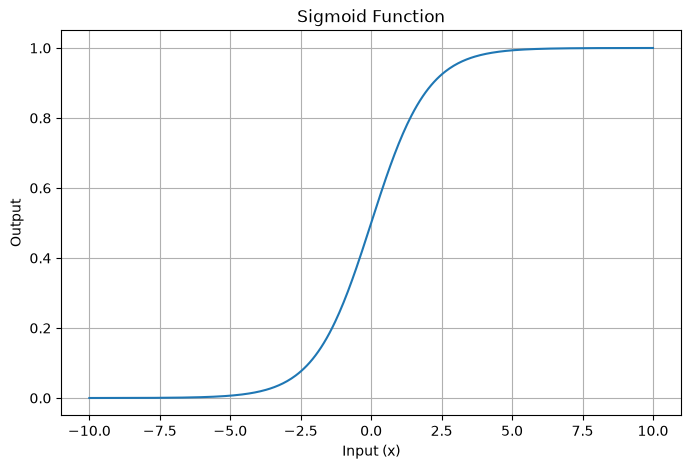

In [53]:
import matplotlib.pyplot as plt

plot_x = np.linspace(-10, 10, 400)
plot_y = 1 / (1 + np.exp(-plot_x))

plt.figure(figsize=(8, 5))
plt.plot(plot_x, plot_y)
plt.title("Sigmoid Function")
plt.xlabel("Input (x)")
plt.ylabel("Output")
plt.grid(True)
plt.show()

In [54]:
def sigmoid(x):
    return(1 / (1 + np.exp(-x)))

In [55]:
values = np.array([-100, -10, -2, -1, 0, 1, 2, 10, 100])

for value in values:
    print(f"{value:>5} -> {sigmoid(value):.6f}")

 -100 -> 0.000000
  -10 -> 0.000045
   -2 -> 0.119203
   -1 -> 0.268941
    0 -> 0.500000
    1 -> 0.731059
    2 -> 0.880797
   10 -> 0.999955
  100 -> 1.000000


## Why does this help?

Instead of predicting any real number,

Linear Regression:

42  
-8  
3.7 

Logistic Regression first computes a number and then passes it through the sigmoid function.

For example,

Raw Model Output → Sigmoid Output

-5 → 0.0067

0 → 0.5000

2 → 0.8808

8 → 0.9997

Now every prediction lies between 0 and 1.

This allows us to interpret the output as a **probability**.

## From Probability to a Decision

The sigmoid function gives us a probability between **0 and 1**.

For example,

| Sigmoid Output | Interpretation |
|---------------|----------------|
| 0.12 | 12% chance of belonging to Class 1 |
| 0.48 | 48% chance of belonging to Class 1 |
| 0.73 | 73% chance of belonging to Class 1 |
| 0.95 | 95% chance of belonging to Class 1 |

However, our model must ultimately make a decision.

Should the prediction be **Class 0** or **Class 1**?

## Decision Boundary

A **Decision Boundary** is simply a threshold used to convert a probability into a class.

For binary classification, the most common threshold is **0.5**.

Rule:

If Probability ≥ 0.5 → Predict Class 1

If Probability < 0.5 → Predict Class 0

This works because the sigmoid function outputs exactly **0.5** when its input is zero.

In [56]:
probabilities = np.array([0.05, 0.28, 0.49, 0.50, 0.73, 0.91])

predictions = (probabilities >= 0.5).astype(int)

for probability, prediction in zip(probabilities, predictions):
    print(f"Probability = {probability:.2f} --> Predicted Class = {prediction}")

Probability = 0.05 --> Predicted Class = 0
Probability = 0.28 --> Predicted Class = 0
Probability = 0.49 --> Predicted Class = 0
Probability = 0.50 --> Predicted Class = 1
Probability = 0.73 --> Predicted Class = 1
Probability = 0.91 --> Predicted Class = 1


## Why 0.5?

Remember that the sigmoid curve is perfectly symmetric.

- An input of **0** produces an output of **0.5**.
- Values greater than **0** produce probabilities greater than **0.5**.
- Values less than **0** produce probabilities less than **0.5**.

Therefore, using **0.5** as the decision boundary naturally separates the two classes.

Although 0.5 is the most common threshold, it is **not mandatory**.

For example:

- Medical diagnosis may use a lower threshold (such as 0.3) to detect more positive cases.
- Spam filters may use a higher threshold (such as 0.8) to reduce false positives.

The threshold depends on the problem being solved.

Input Features    
      ▼     
Linear Equation   
(z = wx + b)      
      ▼     
Sigmoid Function  
      ▼     
Probability 
(0 to 1)    
      ▼     
Decision Boundary (0.5)       
      ▼     
Predicted Class (0 or 1)      

## Measuring the Model's Error

Our model now predicts probabilities.

For example,

Prediction = 0.91

Actual = 1

This seems like a good prediction.

Now consider another prediction.

Prediction = 0.12

Actual = 1

This is clearly much worse.

We now need a loss function that tells the model **how wrong** its predictions are.

Can we simply use Mean Squared Error (MSE)?

## Why Not Mean Squared Error?

Suppose the true class is:

Actual = 1

Now compare two predictions.

Prediction A = 0.90

Prediction B = 0.10

Using Mean Squared Error,

Error(A) = (1 - 0.90)² = 0.01

Error(B) = (1 - 0.10)² = 0.81

Although Prediction B is worse, MSE does not penalize extremely confident wrong predictions strongly enough.

For classification, we want the penalty to become **very large** when the model is highly confident but completely wrong.

This leads us to Binary Cross-Entropy Loss.

## Binary Cross-Entropy Loss

Binary Cross-Entropy measures how close the predicted probability is to the actual class.

Its mathematical equation is

\[
L = -\left(y\log(p) + (1-y)\log(1-p)\right)
\]

where

- \(y\) is the true class (0 or 1)
- \(p\) is the predicted probability

Notice that only one of the two terms is active.

If the true class is 1,

\[
L=-\log(p)
\]

If the true class is 0,

\[
L=-\log(1-p)
\]

This means the model is always penalized based on the probability it assigned to the correct class.

## Why Logarithms?

The logarithm has an important property.

If the model is correct and confident,

Probability = 0.99

Loss is very small.

If the model is wrong but uncertain,

Probability = 0.50

Loss is moderate.

If the model is wrong and extremely confident,

Probability = 0.001

Loss becomes very large.

This encourages the model to avoid making confident but incorrect predictions.

Imagine a doctor says:

"I'm 99% sure you don't have the disease," but you're actually sick.

That's much worse than saying:

"I'm 55% sure you don't have the disease."

Binary Cross-Entropy reflects this intuition by assigning a much larger penalty to confident mistakes than to uncertain ones.

In [57]:
def binary_cross_entropy(y_true, y_pred):
    epsilon = 1e-15
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)

    return -(y_true * np.log(y_pred) +
             (1 - y_true) * np.log(1 - y_pred))

In [58]:
predictions = np.array([0.99, 0.90, 0.70, 0.50, 0.20, 0.01])

losses = binary_cross_entropy(1, predictions)

for probability, loss in zip(predictions, losses):
    print(f"Prediction = {probability:.2f} --> Loss = {loss:.4f}")

Prediction = 0.99 --> Loss = 0.0101
Prediction = 0.90 --> Loss = 0.1054
Prediction = 0.70 --> Loss = 0.3567
Prediction = 0.50 --> Loss = 0.6931
Prediction = 0.20 --> Loss = 1.6094
Prediction = 0.01 --> Loss = 4.6052


## Key Insight

Notice how the loss increases rapidly as the predicted probability for the correct class decreases.

Unlike Mean Squared Error, Binary Cross-Entropy strongly penalizes predictions that are both **wrong and highly confident**.

This makes it the standard loss function for Logistic Regression and many other binary classification models.

## Initializing the Model Parameters

Like Linear Regression, our model starts with two parameters:

- Weight (w)
- Bias (b)

Initially, the model has no knowledge of the data.

So we simply initialize both parameters to zero.

During training, Gradient Descent will gradually update these values to minimize the loss.

In [59]:
weight = 0.0
bias = 0.0

learning_rate = 0.1
epochs = 1000

## Forward Pass

For every input feature, the model first computes a linear output.

\[
z = wx + b
\]

This value is called the **logit**.

The logit is then passed through the sigmoid function to obtain a probability.

The complete forward pass is therefore:

Input

↓

Linear Equation

↓

Sigmoid Function

↓

Probability

In [60]:
z = weight * X + bias
predictions = sigmoid(z)

print("Logits:", z)
print("Probabilities:", predictions)

Logits: [0. 0. 0. 0. 0. 0. 0. 0.]
Probabilities: [0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]


## Computing the Loss

Now that we have predicted probabilities, we compare them with the actual labels using Binary Cross-Entropy Loss.

The loss tells us how well the model is performing.

Our goal during training is to minimize this loss.

In [61]:
loss = np.mean(binary_cross_entropy(y, predictions))

print("Loss:", loss)

Loss: 0.6931471805599453


## Computing the Gradients

The gradients tell us how the weight and bias should change to reduce the loss.

For Logistic Regression, the gradients are

\[
\frac{\partial L}{\partial w}
=
\frac{1}{n}\sum (p-y)x
\]

\[
\frac{\partial L}{\partial b}
=
\frac{1}{n}\sum (p-y)
\]

where

- \(p\) is the predicted probability.
- \(y\) is the true label.

In [62]:
errors = predictions - y

gradient_w = np.mean(errors * X)
gradient_b = np.mean(errors)

print("Gradient (Weight):", gradient_w)
print("Gradient (Bias):", gradient_b)

Gradient (Weight): -1.0
Gradient (Bias): 0.0


## Updating the Parameters

The gradients tell us how the loss changes with respect to the model parameters.

We use **Gradient Descent** to move the parameters in the direction that reduces the loss.

The update rules are

Weight Update

\[
w = w - \alpha \frac{\partial L}{\partial w}
\]

Bias Update

\[
b = b - \alpha \frac{\partial L}{\partial b}
\]

where

- \(w\) is the weight
- \(b\) is the bias
- \(\alpha\) is the learning rate

These updates are repeated many times until the model learns the optimal parameters.

In [63]:
weight -= learning_rate * gradient_w
bias -= learning_rate * gradient_b

print("Updated Weight:", weight)
print("Updated Bias:", bias)

Updated Weight: 0.1
Updated Bias: 0.0


In [64]:
weight = 0.0
bias = 0.0

learning_rate = 0.1
epochs = 1000

loss_history = []

for epoch in range(epochs):

    # Forward Pass
    z = weight * X + bias
    predictions = sigmoid(z)

    # Loss
    loss = np.mean(binary_cross_entropy(y, predictions))
    loss_history.append(loss)

    # Gradients
    errors = predictions - y
    gradient_w = np.mean(errors * X)
    gradient_b = np.mean(errors)

    # Update
    weight -= learning_rate * gradient_w
    bias -= learning_rate * gradient_b

    if epoch % 100 == 0:
        print(f"Epoch {epoch:4d} | Loss = {loss:.6f}")

Epoch    0 | Loss = 0.693147
Epoch  100 | Loss = 0.342032
Epoch  200 | Loss = 0.256761
Epoch  300 | Loss = 0.213729
Epoch  400 | Loss = 0.187275
Epoch  500 | Loss = 0.169029
Epoch  600 | Loss = 0.155484
Epoch  700 | Loss = 0.144909
Epoch  800 | Loss = 0.136345
Epoch  900 | Loss = 0.129215


## Training Complete

After many epochs, the loss should decrease significantly.

The model has now learned the relationship between the input feature and the output classes.

In [65]:
z = weight * X + bias
probabilities = sigmoid(z)
predicted_classes = (probabilities >= 0.5).astype(int)

print("Hours | Probability | Prediction | Actual")
print("-" * 42)

for x, p, pred, actual in zip(X, probabilities, predicted_classes, y):
    print(f"{int(x):5d} | {p:.4f}      | {pred:^10d} | {int(actual)}")

Hours | Probability | Prediction | Actual
------------------------------------------
    0 | 0.0049      |     0      | 0
    1 | 0.0239      |     0      | 0
    2 | 0.1082      |     0      | 0
    3 | 0.3759      |     0      | 0
    4 | 0.7493      |     1      | 1
    5 | 0.9368      |     1      | 1
    6 | 0.9866      |     1      | 1
    7 | 0.9973      |     1      | 1


## Conclusion

In this notebook, we built Logistic Regression completely from scratch using only NumPy.

We learned:

- Why Linear Regression cannot solve classification problems.
- How the sigmoid function converts real numbers into probabilities.
- How the decision boundary converts probabilities into class labels.
- Why Binary Cross-Entropy is the preferred loss function for binary classification.
- How Gradient Descent updates the model parameters.
- How repeated training enables the model to learn from data.

This completes one of the most important supervised learning algorithms.

Next: **Neural Networks from Scratch**.